# Group 4 | Nancy Melchert, Sophia Menchaca, Blythe Weng

## Galaxy Classification

# INFORMATION ABOUT THE DATASET

From the [zenodo.org](https://zenodo.org/records/11117528) site:

## Overview

GalaxiesML is a machine learning-ready dataset of galaxy images, photometry, redshifts, and structural parameters. It is designed for machine learning applications in astrophysics, particularly for tasks such as redshift estimation and galaxy morphology classification. The dataset comprises **286,401 galaxy images** from the Hyper-Suprime-Cam (HSC) Survey PDR2 in five filters: g, r, i, z, y, with spectroscopically confirmed redshifts as ground truth.

This dataset is particularly useful for developing machine learning models for upcoming large-scale surveys like **LSST** and **Euclid**.

## Features

- **286,401 galaxy images** in five photometric bands (g, r, i, z, y).
- Spectroscopic redshifts for each galaxy, with redshift values ranging from **0.01 to 4**.
- Morphological parameters derived from galaxy images, including **Sérsic index**, **half-light radius**, and **ellipticity**.
- **Machine learning-friendly formats**: images are provided in **HDF5** format, along with CSV metadata.


## Examples of Using GalaxiesML

Examples of uses of GalaxiesML are outlined in Do et al. (2024). The repository for example code are here:

https://github.com/astrodatalab/galaxiesml_examples


## Citation

Please cite the following papers if you use this dataset in your work:

1. **GalaxiesML Dataset**:
- Do, T. et al., *GalaxiesML: A Dataset of Galaxy Images, Photometry, Redshifts, and Structural Parameters for Machine Learning*. arXiv:2410.00271 (2024), https://arxiv.org/abs/2410.00271 

2. **Hyper Suprime-Cam Subaru Strategic Program (HSC PDR2)**:
- Aihara, H., et al., *Second Data Release of the Hyper Suprime-Cam Subaru Strategic Program*. Publications of the Astronomical Society of Japan, 71(6), 114 (2019). DOI: [10.1093/pasj/psz103](https://doi.org/10.1093/pasj/psz103)

3. **Spectroscopic Surveys**:
- Several publicly available spectroscopic redshift catalogs were used in creating this dataset. Notable sources include:
- **zCOSMOS Survey**: Lilly, S. J., et al., *The zCOSMOS 10k-Bright Spectroscopic Sample*. The Astrophysical Journal Supplement Series, 184(2), 218-229 (2009). DOI: [10.1088/0067-0049/184/2/218](https://doi.org/10.1088/0067-0049/184/2/218)
- **VIMOS Public Extragalactic Survey (VIPERS)**: Garilli, B., et al., *The VIMOS Public Extragalactic Survey (VIPERS): First Data Release of 57,204 Spectroscopic Measurements*. Astronomy & Astrophysics, 562, A23 (2014). DOI: [10.1051/0004-6361/201322790](https://doi.org/10.1051/0004-6361/201322790)
- **DEEP2 Survey**: Newman, J. A., et al., *The DEEP2 Galaxy Redshift Survey: Design, Observations, Data Reduction, and Redshifts*. The Astrophysical Journal Supplement Series, 208(1), 5 (2013). DOI: [10.1088/0067-0049/208/1/5](https://doi.org/10.1088/0067-0049/208/1/5)


## How to Access

The dataset is publicly available on **Zenodo** with the DOI: **[10.5281/zenodo.11117528](https://doi.org/10.5281/zenodo.11117528)**.

## License

This dataset is licensed under a **Creative Commons Attribution 4.0 International License (CC BY 4.0)**. You are free to share and adapt the dataset as long as appropriate credit is given. For more details, visit: **[CC BY 4.0 License](https://creativecommons.org/licenses/by/4.0/)**.

Please cite the references mentioned above if you use this dataset in your work.

# DOWNLOAD AND EXPLORE THE DATASET

Datasets are `.hdf5`. The h5py package is a Pythonic interface to the HDF5 binary data format. 
[H5PY Documentation](https://docs.h5py.org/en/stable/)

In [18]:
# install appropriate libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog

try:
    import h5py
except ImportError: 
    %pip install h5py

In [19]:
# Install Hugging Face datasets
%matplotlib inline
try:
    from datasets import load_dataset
except ImportError:
    %pip install datasets

## MLGalaxies Data

In [4]:
# Prompt user for the HDF5 file path for portability
# TODO: Update this to use a config file or environment variable for better reproducibility

Tk().withdraw()  # Hide the main window
Tk().attributes("-topmost", True)  # Bring the file dialog to the front

hdf5_path = filedialog.askopenfilename(
    title="Select HDF5 file for training", 
    filetypes=[("HDF5 files", "*.hdf5"), ("All files", "*.*")])

Tk().destroy()  # Close the file dialog

if not hdf5_path:
    raise ValueError("No file selected. Please select an HDF5 file.")
with h5py.File(hdf5_path, "r") as f:
    print("Keys in the HDF5 file:", list(f.keys()))
    images = f['image'][:]

Keys in the HDF5 file: ['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'image', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness', 'r_petro_rad', 'r_pos_angle', 'r_sersic_index', 'ra', 'skymap_id', 'specz_dec', 'sp

In [5]:
print("Total Images:", images.shape[0])

Total Images: 204573


In [6]:
# csv files are inside a data folder, but then in .gitignore because of the size, so we need to specify the path to read them

images_df = pd.read_csv("data/5x127x127_training_with_morphology.csv")
print("CSV DataFrame shape:", images_df.shape)

CSV DataFrame shape: (204573, 84)


In [8]:
images_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204573 entries, 0 to 204572
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   coord                         204573 non-null  object 
 1   dec                           204573 non-null  float64
 2   g_central_image_pop_10px_rad  204573 non-null  int64  
 3   g_central_image_pop_15px_rad  204573 non-null  int64  
 4   g_central_image_pop_5px_rad   204573 non-null  int64  
 5   g_cmodel_mag                  204573 non-null  float64
 6   g_cmodel_magsigma             204573 non-null  float64
 7   g_ellipticity                 204573 non-null  float64
 8   g_half_light_radius           204573 non-null  float64
 9   g_isophotal_area              204573 non-null  float64
 10  g_major_axis                  204573 non-null  float64
 11  g_minor_axis                  204573 non-null  float64
 12  g_peak_surface_brightness     204573 non-nul

In [9]:
images_df.describe()

,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,g_major_axis,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
count,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,...,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000
mean,4.819285,1.015862,1.033543,0.998133,21.256327,0.009995,0.229963,6.508896,698.924804,5.528036,...,0.006686,0.231929,5.891219,803.493164,5.732100,4.060182,-6.812149,6.257465,1.829148,1.657161
std,14.836012,0.201299,0.242275,0.158129,1.888613,0.066851,0.171878,3.643963,912.827984,4.107583,...,0.033624,0.167484,3.168950,878.649336,3.687718,2.153258,1.429269,1.410914,52.351394,0.860905
min,-7.227071,0.000000,0.000000,0.000000,14.365486,0.000128,0.000000,-11.244000,0.000000,0.000000,...,0.000097,0.000000,0.000000,0.000000,0.000000,0.000000,-10.623000,0.000000,-90.000000,0.000000
25%,-0.963948,1.000000,1.000000,1.000000,19.719109,0.001517,0.094000,3.873000,121.000000,2.685000,...,0.000996,0.099000,3.678000,146.000000,2.827000,2.302000,-7.827900,5.280000,-43.810000,1.031000
50%,0.325055,1.000000,1.000000,1.000000,21.503017,0.004896,0.189000,5.667000,261.000000,3.917000,...,0.002083,0.195000,5.219000,491.000000,4.911000,3.726000,-6.994000,5.940000,3.600000,1.520000
75%,1.724730,1.000000,1.000000,1.000000,22.624615,0.011667,0.328000,7.991000,954.000000,7.273000,...,0.005968,0.326000,7.161000,1138.000000,7.514000,5.253000,-5.919700,6.600000,47.470000,2.093000
max,53.259826,3.000000,4.000000,3.000000,29.835554,28.564775,0.976000,42.020000,7530.000000,39.735000,...,12.755774,0.933000,40.717000,7534.000000,41.670000,16.890000,0.000000,10.560000,90.000000,9.915000


In [10]:
images_df.head()

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.002657,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.002538,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.002606,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.005510,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.003021,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187


## JWST Dataset

In [16]:
# Image Samples
# This code is from the MultimodalUniverse Github repository, which is the source of our dataset. 
# It loads the dataset using Hugging Face's `datasets` library and retrieves an example to inspect its structure.
# Collab notebook: https://colab.research.google.com/github/MultimodalUniverse/MultimodalUniverse/blob/main/notebooks/getting_started.ipynb

dset_ls = load_dataset("MultimodalUniverse/jwst", 
                       streaming=True, 
                       split="train")
dset_ls = dset_ls.with_format("numpy")
dset_iterator = iter(dset_ls)

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

In [14]:
example = next(dset_iterator)

In [15]:
example.keys()

dict_keys(['image', 'mag_auto', 'flux_radius', 'flux_auto', 'fluxerr_auto', 'cxx_image', 'cyy_image', 'cxy_image', 'object_id'])

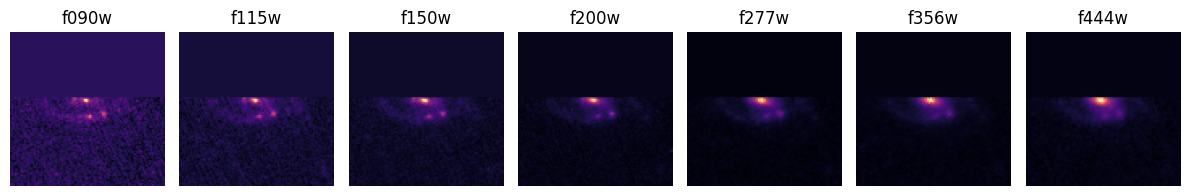

: 

In [ ]:
plt.figure(figsize=(12, 5))
n_bands = len(example["image"]["band"])
for i, b in enumerate(example["image"]["band"]):
    plt.subplot(1, n_bands, i + 1)
    plt.title(f"{b}")
    plt.imshow(example["image"]["flux"][i], cmap="magma")
    plt.axis("off")
plt.tight_layout()


Info about the photometric filters used in the JWST dataset: https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument/miri-instrumentation/miri-filters-and-dispersers#gsc.tab=0